<a href="https://colab.research.google.com/github/Udaybhan2023/credit-card-fraud-detection/blob/main/credit_card_froud_detection_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.metrics import precision_recall_curve, PrecisionRecallDisplay

In [2]:
# --- Data Loading and Initial Exploration ---
print("--- Data Loading and Initial Exploration ---")

# Corrected path to the CSV file after extraction
df = pd.read_csv('/content/creditcard.csv')

print(df.head(5))
print(df.info())
print(df.isnull().sum())

# --- Handle Duplicates ---
# Note: This will create a new DataFrame without duplicates.
df = df.drop_duplicates()
print(f"\nShape after dropping duplicates: {df.shape}")

# --- Descriptive Statistics ---
print("\n--- Descriptive Statistics ---")
print(df.describe())

--- Data Loading and Initial Exploration ---
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -

In [3]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,...,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000,283726.000000
mean,94811.077600,0.005917,-0.004135,0.001613,-0.002966,0.001828,-0.001139,0.001801,-0.000854,-0.001596,...,-0.000371,-0.000015,0.000198,0.000214,-0.000232,0.000149,0.001763,0.000547,88.472687,0.001667
std,47481.047891,1.948026,1.646703,1.508682,1.414184,1.377008,1.331931,1.227664,1.179054,1.095492,...,0.723909,0.724550,0.623702,0.605627,0.521220,0.482053,0.395744,0.328027,250.399437,0.040796
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-15.430084,0.000000,0.000000
25%,54204.750000,-0.915951,-0.600321,-0.889682,-0.850134,-0.689830,-0.769031,-0.552509,-0.208828,-0.644221,...,-0.228305,-0.542700,-0.161703,-0.354453,-0.317485,-0.326763,-0.070641,-0.052818,5.600000,0.000000
50%,84692.500000,0.020384,0.063949,0.179963,-0.022248,-0.053468,-0.275168,0.040859,0.021898,-0.052596,...,-0.029441,0.006675,-0.011159,0.041016,0.016278,-0.052172,0.001479,0.011288,22.000000,0.000000
75%,139298.000000,1.316068,0.800283,1.026960,0.739647,0.612218,0.396792,0.570474,0.325704,0.595977,...,0.186194,0.528245,0.147748,0.439738,0.350667,0.240261,0.091208,0.078276,77.510000,0.000000
max,172792.000000,2.454930,22.057729,9.382558,16.875344,34.801666,73.301626,120.589494,20.007208,15.594995,...,27.202839,10.503090,22.528412,4.584549,7.519589,3.517346,31.612198,33.847808,25691.160000,1.000000


In [4]:
# --- Outlier Detection in 'Amount' ---
print("\n--- Outlier Detection in 'Amount' ---")
Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Amount'] < lower_bound) | (df['Amount'] > upper_bound)]

print(f"Number of outliers in 'Amount' column: {len(outliers)}")
print("Outliers (first 5 rows):\n", outliers.head())
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")


--- Outlier Detection in 'Amount' ---
Number of outliers in 'Amount' column: 31685
Outliers (first 5 rows):
     Time        V1        V2        V3        V4        V5        V6  \
2    1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
20  16.0  0.694885 -1.361819  1.029221  0.834159 -1.191209  1.309109   
51  36.0 -1.004929 -0.985978 -0.038039  3.710061 -6.631951  5.122103   
64  42.0 -0.522666  1.009923  0.276470  1.475289 -0.707013  0.355243   
85  55.0 -4.575093 -4.429184  3.402585  0.903915  3.002224 -0.491078   

          V7        V8        V9  ...       V21       V22       V23       V24  \
2   0.791461  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281   
20 -0.878586  0.445290 -0.446196  ... -0.295583 -0.571955 -0.050881 -0.304215   
51  4.371691 -2.006868 -0.278736  ...  1.393406 -0.381671  0.969719  0.019445   
64  1.559849 -0.399579 -0.479813  ...  0.172401  1.011543  0.069666  0.157820   
85 -2.705393  0.666451  1.922216  ... -0.047365  0.8

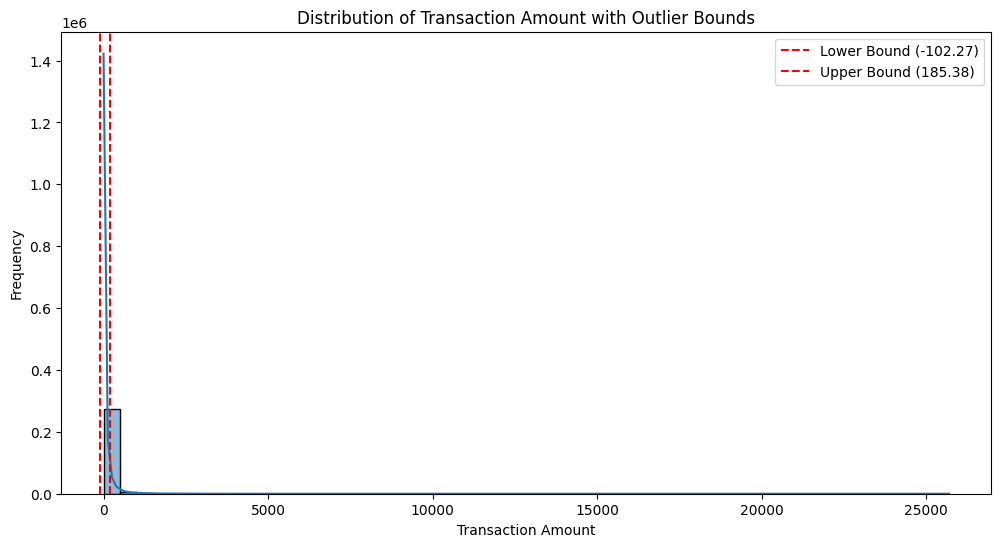

In [5]:

# --- Visualize Amount Distribution ---
plt.figure(figsize=(12, 6))
sns.histplot(df['Amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amount with Outlier Bounds')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.axvline(lower_bound, color='r', linestyle='--', label=f'Lower Bound ({lower_bound:.2f})')
plt.axvline(upper_bound, color='r', linestyle='--', label=f'Upper Bound ({upper_bound:.2f})')
plt.legend()
plt.show()

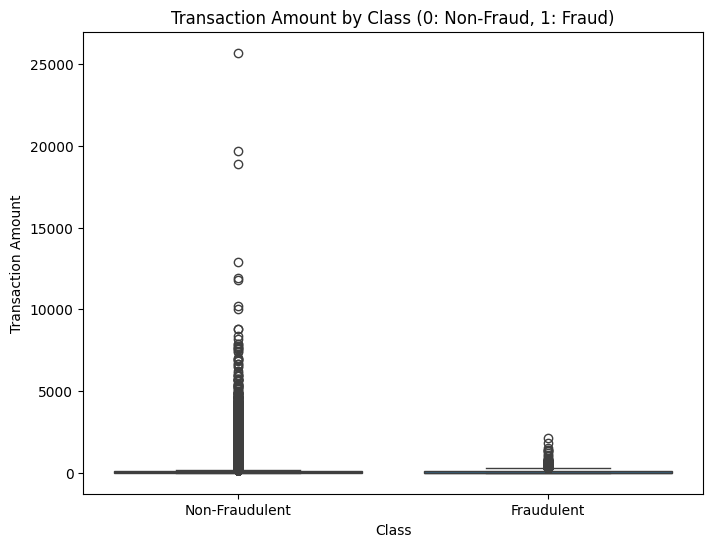

In [6]:

# --- Boxplot of Amount by Class ---
plt.figure(figsize=(8, 6))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class (0: Non-Fraud, 1: Fraud)')
plt.xlabel('Class')
plt.ylabel('Transaction Amount')
plt.xticks([0, 1], ['Non-Fraudulent', 'Fraudulent'])
plt.show()

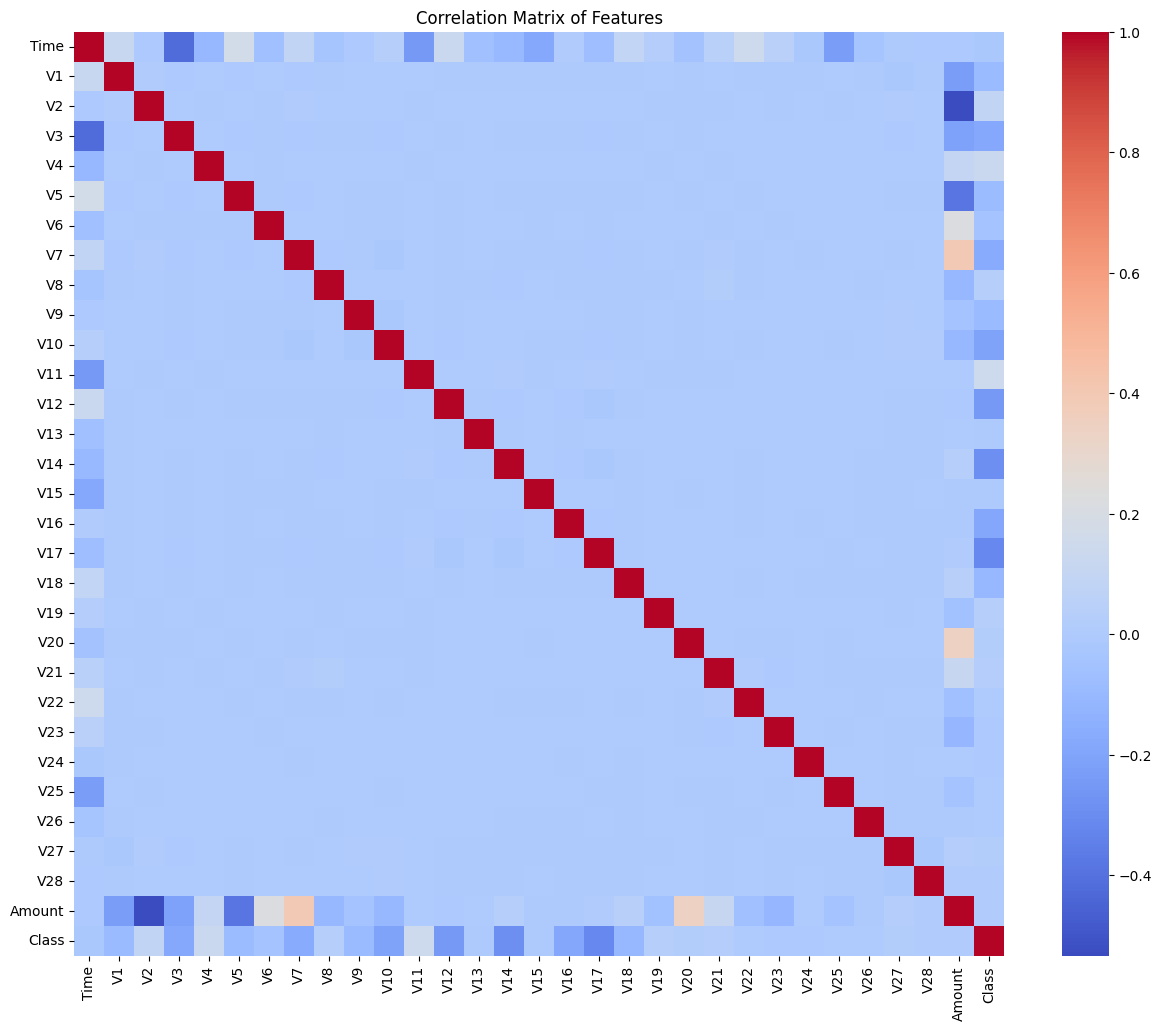

In [7]:
correlation_matrix = df.corr()

plt.figure(figsize=(15, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

In [8]:
# --- Top 5 Correlated Features with 'Class' ---
print("\n--- Top 5 Most Correlated Features with 'Class' ---")
class_correlations = correlation_matrix['Class'].abs().sort_values(ascending=False)
top_5_correlated_features = class_correlations[1:6]
print("Top 5 most highly correlated features with 'Class':")
for feature, correlation in top_5_correlated_features.items():
    actual_correlation = correlation_matrix.loc[feature, 'Class']
    print(f"- {feature}: {actual_correlation:.4f}")



--- Top 5 Most Correlated Features with 'Class' ---
Top 5 most highly correlated features with 'Class':
- V17: -0.3135
- V14: -0.2934
- V12: -0.2507
- V10: -0.2070
- V16: -0.1872


In [9]:

# --- Feature Scaling ---
print("\n--- Feature Scaling ---")
scaler = StandardScaler()
df['Amount_Scaled'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time_Scaled'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
print(df[['Time', 'Time_Scaled', 'Amount', 'Amount_Scaled', 'Class']].head())

# --- Feature Engineering (Interaction Feature) ---
print("\n--- Feature Engineering (Interaction Feature) ---")
df['V17_V14_Interaction'] = df['V17'] * df['V14']
scaler_interaction = StandardScaler()
df['V17_V14_Interaction_Scaled'] = scaler_interaction.fit_transform(df['V17_V14_Interaction'].values.reshape(-1, 1))
print(df[['V17', 'V14', 'V17_V14_Interaction', 'V17_V14_Interaction_Scaled']].head())



--- Feature Scaling ---
   Time  Time_Scaled  Amount  Amount_Scaled  Class
0   0.0    -1.996823  149.62       0.244200      0
1   0.0    -1.996823    2.69      -0.342584      0
2   1.0    -1.996802  378.66       1.158900      0
3   1.0    -1.996802  123.50       0.139886      0
4   2.0    -1.996781   69.99      -0.073813      0

--- Feature Engineering (Interaction Feature) ---
        V17       V14  V17_V14_Interaction  V17_V14_Interaction_Scaled
0  0.207971 -0.311169            -0.064714                   -0.011337
1 -0.114805 -0.143772             0.016506                    0.005764
2  1.109969 -0.165946            -0.184195                   -0.036494
3 -0.684093 -0.287924             0.196967                    0.043761
4 -0.237033 -1.119670             0.265399                    0.058170



# --- Data Splitting ---


In [10]:
print("\n--- Data Splitting ---")
features = ['Time_Scaled', 'Amount_Scaled'] + list(top_5_correlated_features.index)
X = df[features]
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")




--- Data Splitting ---
X_train shape: (226980, 7)
X_test shape: (56746, 7)
y_train shape: (226980,)
y_test shape: (56746,)


In [11]:
# --- Logistic Regression Model ---
print("\n--- Logistic Regression Model ---")
model = LogisticRegression(solver='liblinear', class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
y_pred_lr = model.predict(X_test)
y_prob_lr = model.predict_proba(X_test)[:, 1]
print("Logistic Regression Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


--- Logistic Regression Model ---
Logistic Regression Model Performance:
Accuracy: 0.9757163500511049

Confusion Matrix:
 [[55290  1361]
 [   17    78]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.05      0.82      0.10        95

    accuracy                           0.98     56746
   macro avg       0.53      0.90      0.54     56746
weighted avg       1.00      0.98      0.99     56746



### Random Forest Classifier

Let's train a Random Forest Classifier, which is an ensemble learning method that builds multiple decision trees and merges them to get a more accurate and stable prediction. It's often robust against overfitting and good for imbalanced datasets when `class_weight` is handled.


--- Random Forest Classifier Model ---
Random Forest Classifier Model Performance:
Accuracy: 0.9994713283755683

Confusion Matrix:
 [[56647     4]
 [   26    69]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.73      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746


--- Random Forest Feature Importance ---


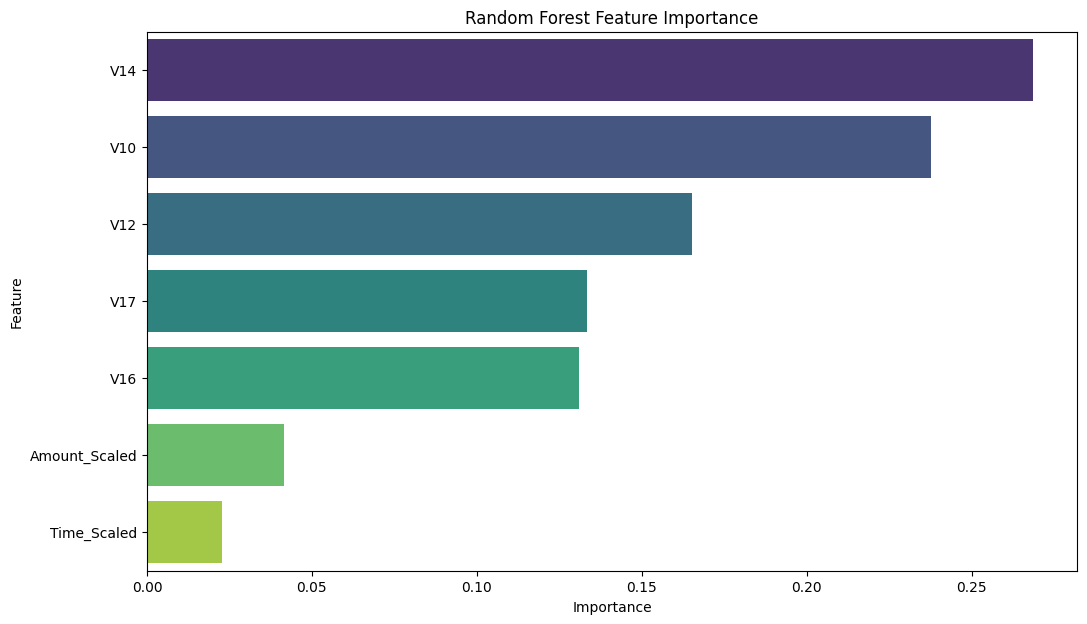

In [12]:
# --- Random Forest Classifier Model ---
print("\n--- Random Forest Classifier Model ---")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print("Random Forest Classifier Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# --- Random Forest Feature Importance ---
print("\n--- Random Forest Feature Importance ---")
feature_importances = rf_model.feature_importances_
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
})
importance_df = importance_df.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


### XGBoost Classifier

Next, let's train an XGBoost Classifier. XGBoost (eXtreme Gradient Boosting) is a powerful and efficient implementation of the gradient boosting framework. It is known for its speed and performance, especially on structured data problems like this one.

In [13]:
# --- XGBoost Classifier Model ---
print("\n--- XGBoost Classifier Model ---")
scale_pos_weight_value = (y_train == 0).sum() / (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    scale_pos_weight=scale_pos_weight_value,
    random_state=42
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]
print("XGBoost Classifier Model Performance:")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))


--- XGBoost Classifier Model ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [01:42:47] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Classifier Model Performance:
Accuracy: 0.9994360836006062

Confusion Matrix:
 [[56642     9]
 [   23    72]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.76      0.82        95

    accuracy                           1.00     56746
   macro avg       0.94      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746



The classification report and confusion matrix provide a detailed breakdown of the model's performance, which is especially important for imbalanced datasets like this one. Due to the imbalance, accuracy alone might be misleading.

### Precision-Recall Curve

To better visualize the trade-off between precision and recall, especially given the imbalanced nature of our dataset, let's plot the precision-recall curves for each model. This will help us understand their performance across different thresholds.


--- Precision-Recall Curve ---


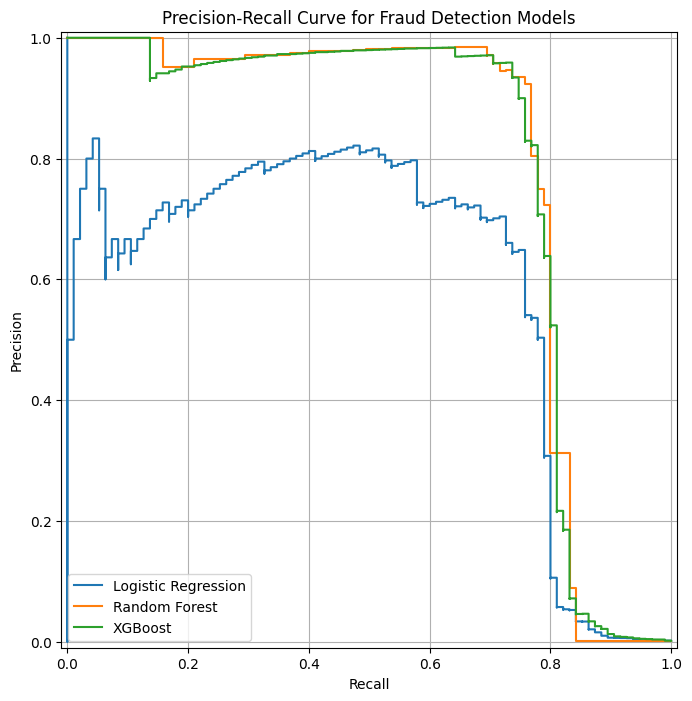

In [14]:

# --- Precision-Recall Curve ---
print("\n--- Precision-Recall Curve ---")
plt.figure(figsize=(10, 8))
prec_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
disp_lr = PrecisionRecallDisplay(precision=prec_lr, recall=recall_lr)
disp_lr.plot(ax=plt.gca(), name='Logistic Regression')
prec_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
disp_rf = PrecisionRecallDisplay(precision=prec_rf, recall=recall_rf)
disp_rf.plot(ax=plt.gca(), name='Random Forest')
prec_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)
disp_xgb = PrecisionRecallDisplay(precision=prec_xgb, recall=recall_xgb)
disp_xgb.plot(ax=plt.gca(), name='XGBoost')
plt.title('Precision-Recall Curve for Fraud Detection Models')
plt.grid(True)
plt.show()

## Summary of Credit Card Fraud Detection Analysis

This analysis focused on building and evaluating machine learning models for credit card fraud detection using the `creditcard.csv` dataset. Key steps and findings include:

1.  **Data Loading & Initial Exploration:**
    *   The `creditcard.csv` dataset was loaded, and an initial exploration of its structure, missing values, and descriptive statistics was performed.
    *   Duplicate rows were identified and removed to ensure data quality.

2.  **Outlier Detection:**
    *   Outliers in the 'Amount' column were identified using the Interquartile Range (IQR) method, highlighting transactions significantly different from the norm.
    *   Visualizations (histogram and boxplot) helped understand the distribution of transaction amounts and their relationship with the 'Class' (fraudulent/non-fraudulent).

3.  **Correlation Analysis:**
    *   A correlation matrix and heatmap were used to explore relationships between features.
    *   The top 5 features most correlated with the 'Class' (V17, V14, V12, V10, V16) were identified as crucial for fraud detection.

4.  **Feature Engineering:**
    *   'Time' and 'Amount' features were scaled using `StandardScaler` to normalize their ranges.
    *   An interaction feature, `V17_V14_Interaction`, was created and scaled, based on highly correlated features, to potentially capture more complex relationships.

5.  **Model Training & Evaluation:**
    *   The dataset was split into training and testing sets (80/20) using stratified sampling to maintain class distribution.
    *   Three models were trained and evaluated:
        *   **Logistic Regression:** Showed high recall for fraud but low precision, indicating many false positives.
        *   **Random Forest Classifier:** Performed significantly better with high accuracy, precision, and recall for fraud, and was robust against overfitting.
        *   **XGBoost Classifier:** Also demonstrated strong performance with a good balance of accuracy, precision, and recall for fraud.
    *   Both Random Forest and XGBoost significantly outperformed Logistic Regression, showcasing their effectiveness for imbalanced classification tasks.

6.  **Performance Visualization:**
    *   Precision-Recall curves were plotted for all three models, visually confirming the superior trade-off between precision and recall achieved by Random Forest and XGBoost, which is critical for imbalanced datasets like this one.

7.  **Feature Importance:**
    *   Feature importances from the Random Forest model were analyzed and visualized, confirming the significance of features like `V14`, `V10`, `V12`, `V17`, and `V16` in predicting fraud.

In [16]:
from sklearn.metrics import classification_report
import pandas as pd

# Function to extract metrics for class '1'
def extract_fraud_metrics(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    metrics = {
        'Model': model_name,
        'Precision (Fraud)': report['1']['precision'],
        'Recall (Fraud)': report['1']['recall'],
        'F1-Score (Fraud)': report['1']['f1-score'],
        'Accuracy': report['accuracy']
    }
    return metrics

# Extract metrics for each model
lr_metrics = extract_fraud_metrics(y_test, y_pred_lr, 'Logistic Regression')
rf_metrics = extract_fraud_metrics(y_test, y_pred_rf, 'Random Forest Classifier')
xgb_metrics = extract_fraud_metrics(y_test, y_pred_xgb, 'XGBoost Classifier')

# Create a DataFrame to display the summary
summary_df = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics])

print("\n--- Model Performance Summary (Fraud Class) ---")
display(summary_df)


--- Model Performance Summary (Fraud Class) ---


,Model,Precision (Fraud),Recall (Fraud),F1-Score (Fraud),Accuracy
0,Logistic Regression,0.054204,0.821053,0.101695,0.975716
1,Random Forest Classifier,0.945205,0.726316,0.821429,0.999471
2,XGBoost Classifier,0.888889,0.757895,0.818182,0.999436


In [18]:
import joblib

# Save the best performing model (Random Forest Classifier)
model_filename = 'random_forest_model.joblib'
joblib.dump(rf_model, model_filename)
print(f"Random Forest model saved as {model_filename}")

Random Forest model saved as random_forest_model.joblib


## Model Deployment

Now that you have saved your trained model, the next steps for deployment typically involve:

1.  **Choosing a Deployment Platform:** Common platforms include:
    *   **Cloud-based services:** Google Cloud AI Platform, AWS SageMaker, Azure Machine Learning.
    *   **Containerization:** Docker with services like Kubernetes.
    *   **Web frameworks:** Flask or FastAPI to create a REST API.

2.  **Creating a Prediction Endpoint:** This involves writing code (e.g., a Python script using Flask/FastAPI) that:
    *   Loads the saved `random_forest_model.joblib` file.
    *   Receives new data (e.g., transaction features) as input.
    *   Uses the loaded model to make predictions.
    *   Returns the prediction results (e.g., fraud/non-fraud probability).

3.  **Handling Preprocessing:** Ensure that any preprocessing steps applied to the training data (like `StandardScaler` for 'Time' and 'Amount') are also applied to new inference data. You might need to save and load the `scaler` objects as well.

4.  **Deployment:** Deploy your prediction endpoint to your chosen platform. This often involves creating a server, installing dependencies, and exposing the API.

**Example (Conceptual Python API using Flask):**

```python
# This is a conceptual example and would typically run in a separate environment.
# You would need to install Flask (`pip install Flask`)

from flask import Flask, request, jsonify
import joblib
import pandas as pd
from sklearn.preprocessing import StandardScaler

app = Flask(__name__)

# Load the model
model = joblib.load('random_forest_model.joblib')

# NOTE: You must also save and load your scalers for Time and Amount
# For demonstration, let's assume `scaler_amount` and `scaler_time` are loaded or recreated with same params.
# In a real scenario, these would be saved and loaded alongside the model.
# For now, we'll use placeholder scalers, which is NOT ideal for production.
# You would need to save `scaler` and `scaler_interaction` from your notebook.

# Recreate (or load) scalers if not saved earlier (LESS RELIABLE approach)
# It's best practice to save and load the actual fitted scalers
# For simplicity, let's assume features are already scaled when they arrive

# If you saved the scalers, you would load them like:
# scaler_amount = joblib.load('amount_scaler.joblib')
# scaler_time = joblib.load('time_scaler.joblib')
# scaler_interaction = joblib.load('interaction_scaler.joblib')

@app.route('/predict', methods=['POST'])
def predict():
    try:
        data = request.get_json(force=True)
        # Convert input data to DataFrame
        input_df = pd.DataFrame([data])

        # Ensure the feature order matches training
        # You need to apply the exact same scaling and feature engineering
        # as during training. This part is crucial and omitted for brevity
        # but would involve loading and applying the saved scalers.
        # Example: input_df['Amount_Scaled'] = scaler_amount.transform(input_df[['Amount']])
        # Example: input_df['Time_Scaled'] = scaler_time.transform(input_df[['Time']])
        # Example: input_df['V17_V14_Interaction_Scaled'] = scaler_interaction.transform(
        #     (input_df['V17'] * input_df['V14']).values.reshape(-1,1)
        # )

        # For this example, we assume input 'data' already contains 'Time_Scaled', 'Amount_Scaled', etc.
        # corresponding to `features` list in the training step.
        features = ['Time_Scaled', 'Amount_Scaled', 'V17', 'V14', 'V12', 'V10', 'V16']
        X_new = input_df[features]

        prediction = model.predict(X_new)
        prediction_proba = model.predict_proba(X_new)[:, 1]

        return jsonify({
            'prediction': int(prediction[0]),
            'probability_fraud': float(prediction_proba[0])
        })

    except Exception as e:
        return jsonify({'error': str(e)}), 400

if __name__ == '__main__':
    # For local development, you would run this via `python your_api_file.py`
    # For production, use a WSGI server like Gunicorn/uWSGI.
    app.run(debug=True, host='0.0.0.0', port=5000)

```

Remember to properly save and load all preprocessing objects (like `StandardScaler` instances) used during training when preparing your model for a production environment.